In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/cleaned/cleaned_sessions.csv')

In [4]:
stages = ['product_page_viewed','calculator_used','cta_clicked','form_started','form_submitted']
funnel = df[stages].mean() * 100
funnel

product_page_viewed    92.54
calculator_used        46.96
cta_clicked            30.04
form_started           23.66
form_submitted         15.58
dtype: float64

## Only 15% of customers are submiting the form 

In [5]:
reached = df[stages].sum()
stage_to_stage = reached / reached.shift(1) * 100
stage_to_stage

product_page_viewed          NaN
calculator_used        50.745624
cta_clicked            63.969336
form_started           78.761651
form_submitted         65.849535
dtype: float64

In [6]:
df.groupby('product')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
product,,,,,
Credit Card,91.893645,46.433204,29.896239,23.605707,14.656291
Insurance Plan,91.292135,43.679775,25.702247,19.241573,12.780899
Personal Loan,93.502013,47.958597,31.282346,25.359402,17.193790
Savings Account,92.750745,48.361470,31.181728,23.932473,16.186693


## Personal loans converts the best percentage

In [ ]:
df.groupby('source')[stages].mean() * 100


,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
source,,,,,
Direct,92.954990,50.293542,31.409002,24.657534,15.264188
Email,93.607955,52.130682,34.232955,28.693182,20.454545
Organic Search,93.134087,44.991922,29.886914,23.505654,16.639742
Paid Ads,89.772727,41.632231,25.413223,18.181818,10.743802
Referral,96.068376,58.119658,40.341880,33.333333,22.735043
Social Media,89.855072,34.575569,18.219462,13.871636,7.453416


## Emails and refferal have best percentage and social media have worst

In [10]:
df['source'].value_counts()

source
Organic Search    1238
Direct            1022
Paid Ads           968
Email              704
Referral           585
Social Media       483
Name: count, dtype: int64

### Most customers are from organic search and social media campains have worst numbers

In [11]:
df.groupby('device')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
device,,,,,
Desktop,93.381136,50.965251,33.811362,27.357970,19.360177
Mobile,92.052744,45.438346,28.545973,22.166785,13.506771
Tablet,92.125984,39.107612,23.097113,17.060367,12.860892


### Dekstop have best percentage due to big screen and easy reading of forms

In [25]:
df['device'].value_counts()

device
Mobile     2806
Desktop    1813
Tablet      381
Name: count, dtype: int64

In [12]:
df.groupby('age_band')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
age_band,,,,,
18-24,91.754386,43.157895,27.894737,21.754386,14.385965
25-34,93.459045,47.967001,29.758397,23.983500,14.908662
35-44,92.461964,48.409405,31.811895,24.896266,16.251729
45-54,91.834452,44.966443,29.865772,23.042506,16.666667
55+,91.603053,47.328244,28.244275,21.882952,15.267176


### Numbers are similar but the age band value counts differs age band 55+ have best convergent rate

In [26]:
df['age_band'].value_counts()

age_band
25-34    1697
35-44    1446
45-54     894
18-24     570
55+       393
Name: count, dtype: int64

In [13]:
df.groupby('income_band')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
income_band,,,,,
100K+,92.947814,49.788434,33.991537,28.631876,19.887165
25K-50K,92.775882,46.814562,29.124005,22.354949,14.618885
50K-100K,92.961165,48.847087,32.099515,25.667476,17.293689
Below 25K,90.960452,41.468927,24.858757,18.531073,10.847458


### People with higher income has best convergent rate

In [27]:
df['income_band'].value_counts()

income_band
25K-50K      1758
50K-100K     1648
Below 25K     885
100K+         709
Name: count, dtype: int64

In [18]:
df[df['form_submitted']==0]['exit_reason'].value_counts(normalize=True) * 100

exit_reason
Technical issue                     24.022743
Comparing alternatives              18.384269
Unclear product value               13.101161
High interest-rate concern          12.959014
Calculator result not attractive     5.259417
Required information unavailable     4.714523
Immediate bounce                     2.629709
Too many required fields             2.606018
Document requirement concern         2.511253
Landing page mismatch                2.298034
Session timeout                      2.132196
Slow page load                       2.084814
Privacy concern                      1.942668
Not ready to explore                 1.824212
Form looked too long                 1.800521
Not ready to apply                   1.729448
Name: proportion, dtype: float64

### Technial issue is the biggest concern and alternatives maybe we need to convinvce them

In [21]:
df.groupby('product')['exit_reason'].value_counts(normalize=True)

product          exit_reason                     
Credit Card      Technical issue                     0.240122
                 Comparing alternatives              0.171733
                 High interest-rate concern          0.132219
                 Unclear product value               0.120061
                 Calculator result not attractive    0.057751
                                                       ...   
Savings Account  Form looked too long                0.021327
                 Too many required fields            0.021327
                 Not ready to explore                0.021327
                 Privacy concern                     0.015403
                 Slow page load                      0.010664
Name: proportion, Length: 64, dtype: float64

In [22]:
df.groupby('form_submitted')[['session_duration_seconds','page_views']].describe()

session_duration_seconds                                       \
                                  count        mean         std   min    25%   
form_submitted                                                                 
0                                4221.0  594.733239  343.358115  15.0  299.0   
1                                 779.0  625.798460  336.563182  15.0  315.0   

                                     page_views                                \
                  50%    75%     max      count      mean       std  min  25%   
form_submitted                                                                  
0               576.0  897.0  1200.0     4221.0  6.476901  3.520455  1.0  3.0   
1               651.0  914.0  1200.0      779.0  6.454429  3.413856  1.0  3.0   

                                 
                50%   75%   max  
form_submitted                   
0               6.0  10.0  12.0  
1               6.0   9.0  12.0

In [23]:
df.groupby('session_month')[stages[-1]].mean() * 100  # form_submitted rate by month

session_month
1    16.284404
2    15.289766
3    15.850816
4    14.643304
5    15.932203
6    15.354839
Name: form_submitted, dtype: float64

In [24]:
df.groupby('is_returning_user')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
is_returning_user,,,,,
0,92.397502,46.212327,29.622590,23.431985,15.693728
1,92.938497,49.050873,31.207289,24.297646,15.261959


In [28]:
df.groupby('region')[stages].mean() * 100

,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted
region,,,,,
Central,93.250000,48.875000,30.375000,23.750000,14.250000
East,91.323693,44.048943,30.255840,22.691880,16.573971
North,93.027523,45.045872,29.174312,22.660550,15.321101
South,92.224409,48.818898,31.397638,24.901575,15.059055
West,92.803347,48.033473,29.288703,24.184100,16.401674


In [29]:
df['region'].value_counts()

region
West       1195
North      1090
South      1016
East        899
Central     800
Name: count, dtype: int64

In [30]:
top_reasons = df[df['form_submitted']==0].groupby('product')['exit_reason'].value_counts(normalize=True).groupby(level=0).head(3)
top_reasons.unstack(level=1) * 100

exit_reason,Technical issue,Comparing alternatives,High interest-rate concern,Unclear product value
product,,,,
Credit Card,24.012158,17.173252,13.221884,NaN
Insurance Plan,23.510467,18.679549,14.653784,NaN
Personal Loan,25.000000,18.194444,NaN,13.541667
Savings Account,22.748815,20.379147,NaN,13.862559


In [33]:
df.head()

,Unnamed: 0,session_id,user_id,session_start,session_date,source,device,region,age_band,income_band,...,product_page_viewed,calculator_used,cta_clicked,form_started,form_submitted,exit_page,exit_reason,estimated_opportunity_value,session_month,session_week
0,0,S000001,U000179,2025-05-20 15:42:34,2025-05-20,Email,Desktop,North,45-54,50K-100K,...,1,0,0,0,0,Product Page Viewed,High interest-rate concern,5699,5,21
1,1,S000002,U001109,2025-06-09 01:31:53,2025-06-09,Email,Desktop,West,55+,100K+,...,1,1,1,1,1,NaN,NaN,0,6,24
2,2,S000003,U000741,2025-01-14 11:16:09,2025-01-14,Organic Search,Mobile,East,35-44,25K-50K,...,1,0,0,0,0,Product Page Viewed,Unclear product value,76835,1,3
3,3,S000004,U001665,2025-02-05 19:19:03,2025-02-05,Email,Desktop,West,25-34,50K-100K,...,1,1,1,1,1,NaN,NaN,0,2,6
4,4,S000005,U001590,2025-02-24 14:28:05,2025-02-24,Paid Ads,Mobile,South,25-34,Below 25K,...,1,0,0,0,0,Product Page Viewed,High interest-rate concern,9572,2,9


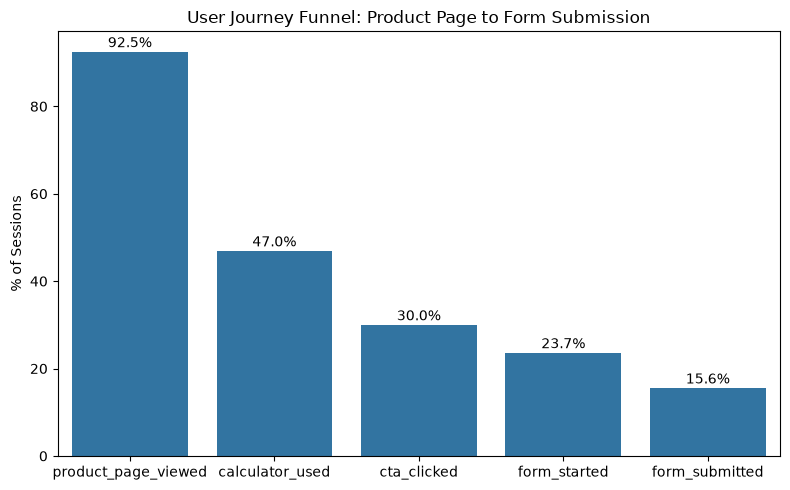

In [39]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=funnel.index, y=funnel.values, ax=ax)
ax.set_title("User Journey Funnel: Product Page to Form Submission")
ax.set_ylabel("% of Sessions")
ax.set_xlabel("")
for i, v in enumerate(funnel.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

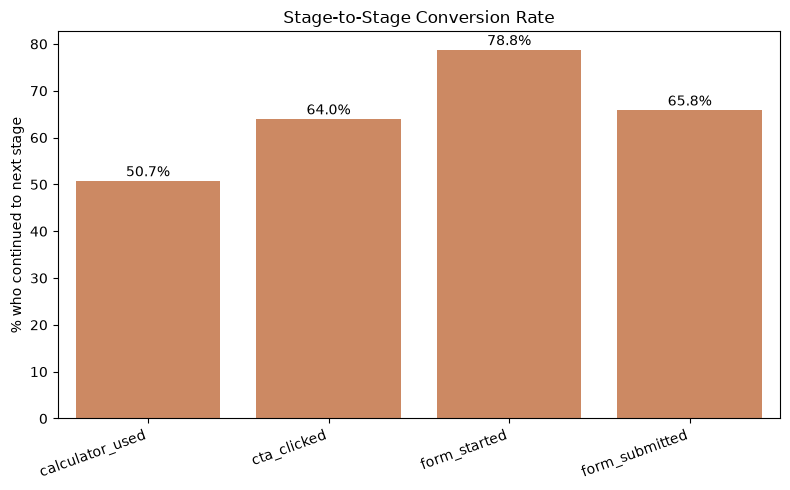

In [41]:
stage_to_stage_clean = stage_to_stage.dropna()  # drops the NaN on product_page_viewed
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=stage_to_stage_clean.index, y=stage_to_stage_clean.values, ax=ax, color="#DD8452")
ax.set_title("Stage-to-Stage Conversion Rate")
ax.set_ylabel("% who continued to next stage")
ax.set_xlabel("")
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(stage_to_stage_clean.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

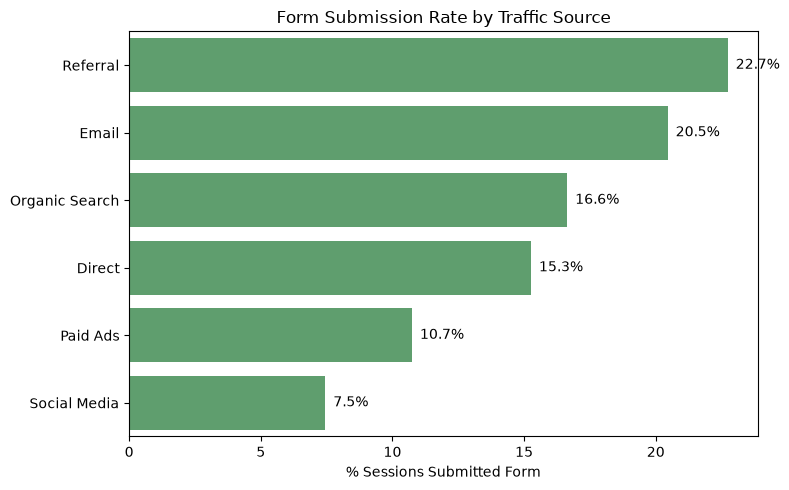

In [42]:
source_conv = df.groupby('source')['form_submitted'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(y=source_conv.index, x=source_conv.values, ax=ax, color="#55A868", orient='h')
ax.set_title("Form Submission Rate by Traffic Source")
ax.set_xlabel("% Sessions Submitted Form")
ax.set_ylabel("")
for i, v in enumerate(source_conv.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va='center')
plt.tight_layout()
plt.show()

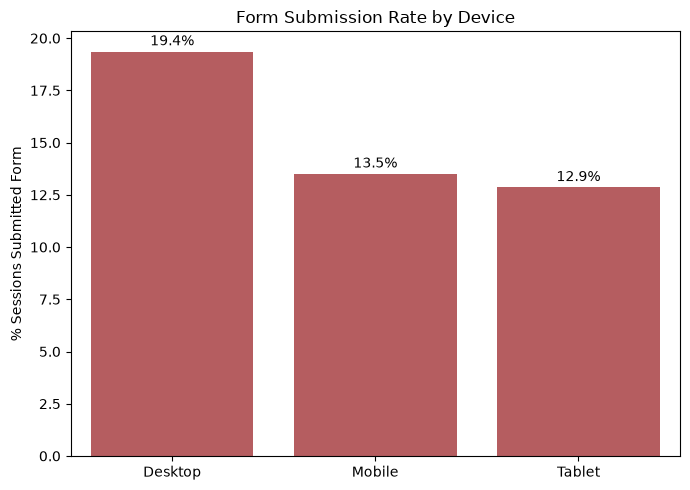

In [43]:
device_conv = df.groupby('device')['form_submitted'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=device_conv.index, y=device_conv.values, ax=ax, color="#C44E52")
ax.set_title("Form Submission Rate by Device")
ax.set_ylabel("% Sessions Submitted Form")
ax.set_xlabel("")
for i, v in enumerate(device_conv.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

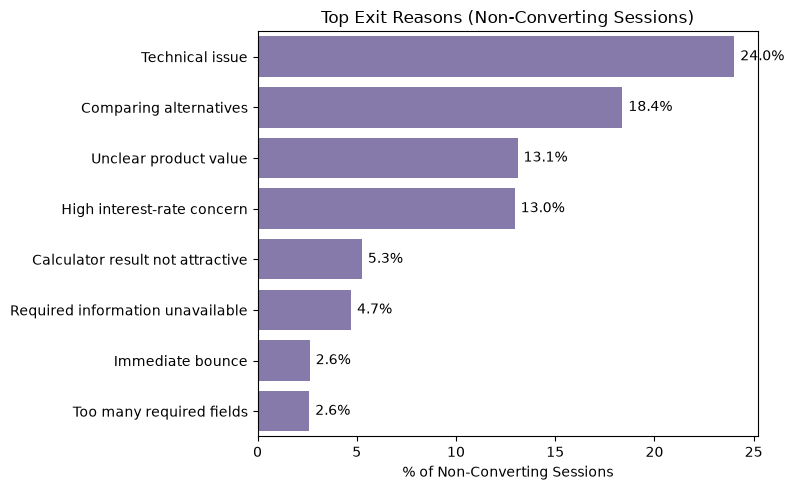

In [44]:
exit_reasons_top = (df[df['form_submitted']==0]['exit_reason']
                     .value_counts(normalize=True)
                     .head(8) * 100)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(y=exit_reasons_top.index, x=exit_reasons_top.values, ax=ax, color="#8172B2", orient='h')
ax.set_title("Top Exit Reasons (Non-Converting Sessions)")
ax.set_xlabel("% of Non-Converting Sessions")
ax.set_ylabel("")
for i, v in enumerate(exit_reasons_top.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va='center')
plt.tight_layout()
plt.show()

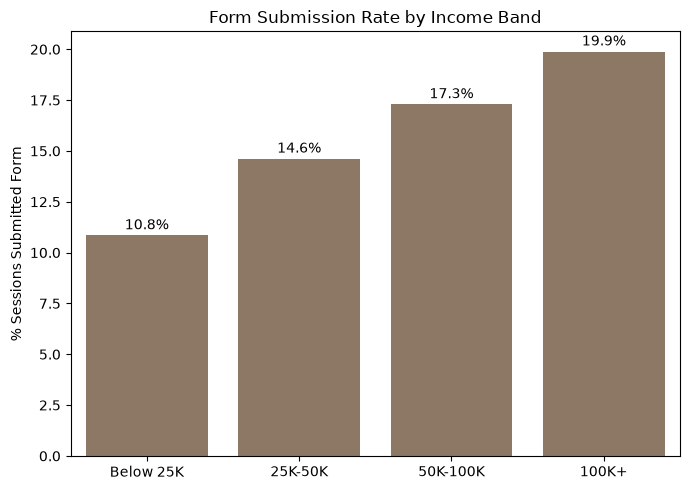

In [45]:
income_order = ['Below 25K', '25K-50K', '50K-100K', '100K+']  # explicit order, not alphabetical
income_conv = df.groupby('income_band')['form_submitted'].mean().reindex(income_order) * 100
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=income_conv.index, y=income_conv.values, ax=ax, color="#937860")
ax.set_title("Form Submission Rate by Income Band")
ax.set_ylabel("% Sessions Submitted Form")
ax.set_xlabel("")
for i, v in enumerate(income_conv.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()